In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

# Load and clean data
df = pd.read_csv("cleaned_bearing_data.csv")

# Drop rows without operational_days or bearing type
df['subscription_start'] = pd.to_datetime(df['subscription_start'])
df['timestamp_of_fault'] = pd.to_datetime(df['timestamp_of_fault'])
df['operational_days'] = (df['timestamp_of_fault'] - df['subscription_start']).dt.days
df = df.dropna(subset=['operational_days', 'bearing_type_assigned_1', 'industry_type'])

# Filter out rare bearing types
type_counts = df['bearing_type_assigned_1'].value_counts()
valid_types = type_counts[type_counts >= 10].index
df = df[df['bearing_type_assigned_1'].isin(valid_types)]


In [3]:
results = []

for bearing_type in df['bearing_type_assigned_1'].unique():
    temp = df[df['bearing_type_assigned_1'] == bearing_type]
    groups = [group['operational_days'].dropna().values for _, group in temp.groupby('industry_type') if len(group) >= 5]

    if len(groups) >= 2:
        f_stat, p_val = f_oneway(*groups)
        results.append({
            "bearing_type": bearing_type,
            "num_industries": len(groups),
            "p_value": round(p_val, 5),
            "is_significant": p_val < 0.05
        })

anova_df = pd.DataFrame(results)
anova_df = anova_df.sort_values(by="p_value")


Text(0.5, 1.0, 'Bearing_296 Lifespan across Industries')

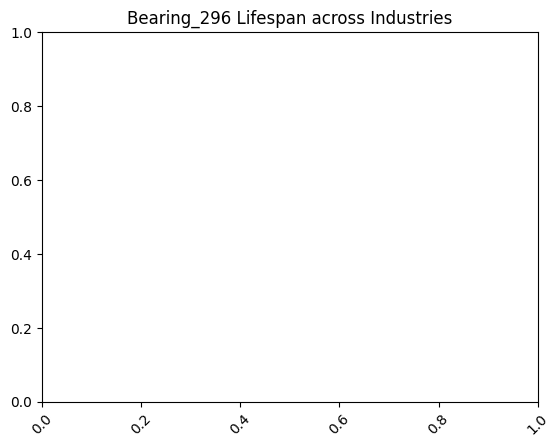

In [4]:
sns.boxplot(data=df[df['bearing_type_assigned_1'] == "Bearing_296"], x='industry_type', y='operational_days')
plt.xticks(rotation=45)
plt.title("Bearing_296 Lifespan across Industries")


In [5]:
anova_df.to_csv("outputs/q2/anova_results.csv", index=False)


In [6]:
# Compute best bearing type per industry (based on average operational_days)
industry_best = (
    df.groupby(['industry_type', 'bearing_type_assigned_1'])['operational_days']
    .agg(['mean', 'count'])
    .reset_index()
)

# Filter only where each bearing_type-industry combo has enough data
industry_best = industry_best[industry_best['count'] >= 5]

# For each industry, pick the bearing type with highest mean life
best_bt_per_industry = (
    industry_best.sort_values(['industry_type', 'mean'], ascending=[True, False])
    .groupby('industry_type')
    .first()
    .reset_index()
    .rename(columns={
        'bearing_type_assigned_1': 'best_bearing_type',
        'mean': 'avg_operational_days',
        'count': 'record_count'
    })
)

# Save to CSV
best_bt_per_industry.to_csv("outputs/q2/best_bearing_per_industry.csv", index=False)


In [7]:
# Heatmap-style bar of bearing performance by industry
pivot_df = industry_best.pivot(index='industry_type', columns='bearing_type_assigned_1', values='mean').fillna(0)

# Save for optional inspection or use
pivot_df.to_csv("outputs/q2/industry_bearing_heatmap.csv")


In [8]:
# Find best industry per bearing type (based on average life)
bearing_best = (
    industry_best.sort_values(['bearing_type_assigned_1', 'mean'], ascending=[True, False])
    .groupby('bearing_type_assigned_1')
    .first()
    .reset_index()
    .rename(columns={
        'industry_type': 'best_industry',
        'mean': 'avg_operational_days',
        'count': 'record_count'
    })
)

# Save to CSV
bearing_best.to_csv("outputs/q2/best_industry_per_bearing.csv", index=False)
